# Multiple Regression, Correlations, Diagnostics, Interactions, and Transformations
**Dataset:** `Auto.csv`

This notebook produces:
- (a) a scatterplot matrix of all variables (excluding `name`),
- (b) correlation matrix,
- (c) a multiple linear regression of `mpg` on all other predictors (except `name`) with ANOVA,
- (d) regression diagnostic plots and identification of influential observations,
- (e) a model with interactions,
- (f) several transformations of `horsepower` and comparison of fit.

In [3]:
# Cell 1: imports + data load + cleanup
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.regressionplots import influence_plot

# Load dataset
df = pd.read_csv("Auto.csv")

# Convert horsepower to numeric and drop rows with missing important values
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['mpg','cylinders','displacement','horsepower','weight','acceleration','year','origin'])

# Quick check
print("Data shape after cleaning:", df.shape)
df.head()

Data shape after cleaning: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


## (a) Scatterplot matrix (all variables except `name`)

<Figure size 1200x1200 with 0 Axes>

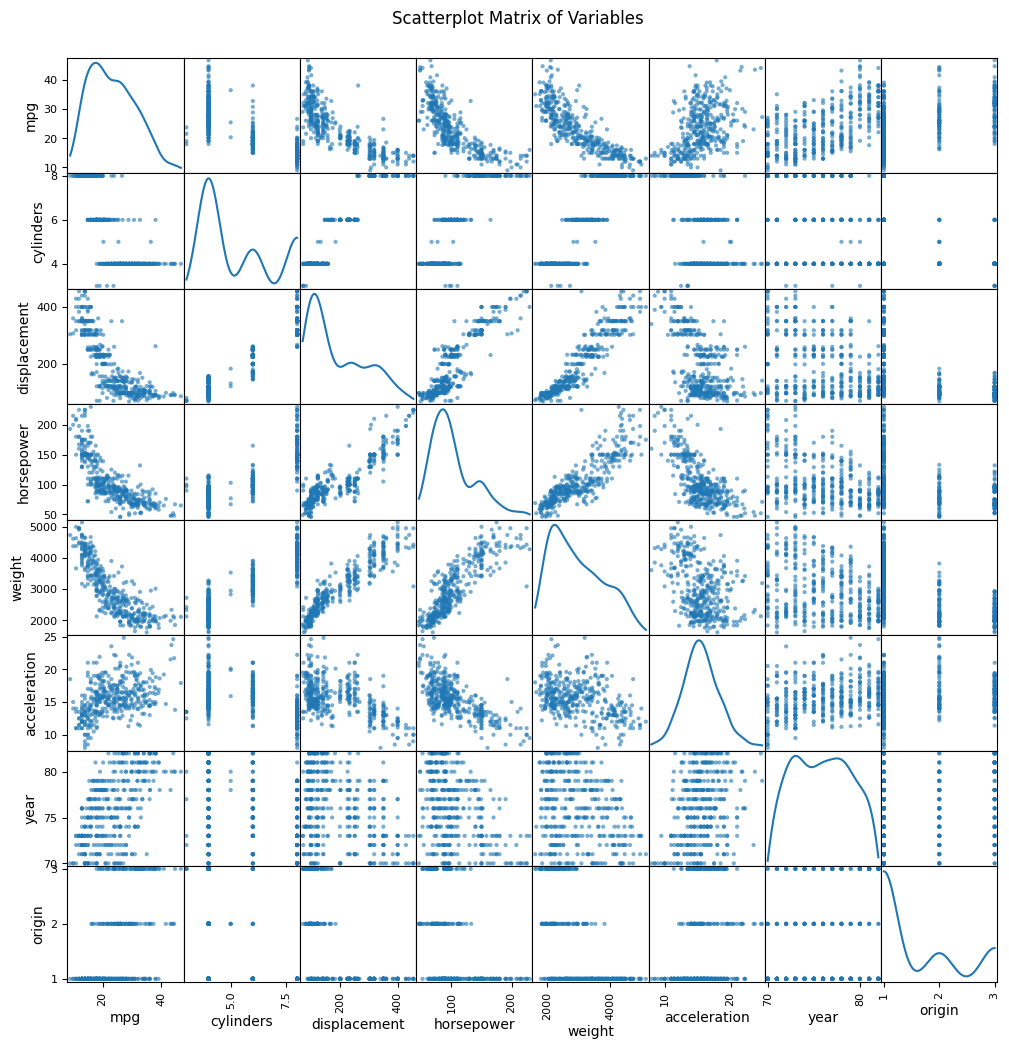

In [4]:
# Cell 2: Scatterplot matrix
vars_for_plot = ['mpg','cylinders','displacement','horsepower','weight','acceleration','year','origin']
plt.figure(figsize=(12,12))
# pandas scatter_matrix uses matplotlib internally
scatter_matrix(df[vars_for_plot], alpha=0.6, diagonal='kde', figsize=(12,12))
plt.suptitle("Scatterplot Matrix of Variables", y=0.92)
plt.show()

## (b) Correlation matrix

In [5]:
# Cell 3: Correlation matrix
corr_matrix = df[vars_for_plot].corr()
print("Correlation matrix (rounded):\n")
print(corr_matrix.round(3))

Correlation matrix (rounded):

                mpg  cylinders  displacement  horsepower  weight  \
mpg           1.000     -0.778        -0.805      -0.778  -0.832   
cylinders    -0.778      1.000         0.951       0.843   0.898   
displacement -0.805      0.951         1.000       0.897   0.933   
horsepower   -0.778      0.843         0.897       1.000   0.865   
weight       -0.832      0.898         0.933       0.865   1.000   
acceleration  0.423     -0.505        -0.544      -0.689  -0.417   
year          0.581     -0.346        -0.370      -0.416  -0.309   
origin        0.565     -0.569        -0.615      -0.455  -0.585   

              acceleration   year  origin  
mpg                  0.423  0.581   0.565  
cylinders           -0.505 -0.346  -0.569  
displacement        -0.544 -0.370  -0.615  
horsepower          -0.689 -0.416  -0.455  
weight              -0.417 -0.309  -0.585  
acceleration         1.000  0.290   0.213  
year                 0.290  1.000   0.182  
orig

## (c) Multiple linear regression: mpg ~ all other predictors (except name)
We use `statsmodels.formula.api.ols()` so we can use `anova_lm()` easily.

In [6]:
# Cell 4: Multiple regression using formula API and ANOVA
formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin"
model_formula = smf.ols(formula, data=df).fit()

# Print full summary
print(model_formula.summary())

# ANOVA (type II)
anova_results = anova_lm(model_formula, typ=2)
print("\nANOVA (Type II):\n", anova_results)

# predictors with p < 0.05
sig_preds = model_formula.pvalues[model_formula.pvalues < 0.05]
print("\nPredictors with p-value < 0.05:\n", sig_preds)

# Interpret coefficient for 'year'
coef_year = model_formula.params['year']
print(f"\nCoefficient for 'year' = {coef_year:.4f}")
print("Interpretation: holding other predictors constant, a 1-unit increase in 'year' is associated with this change in mpg.")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          2.04e-139
Time:                        15:19:10   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644     -3.707   

## (d) Diagnostic plots and influential point detection
We'll produce:
- Residuals vs fitted
- QQ plot of residuals
- Scale-Location (sqrt(|standardized residual|) vs fitted)
- Influence plot (leverage vs Cook's distance)
And list observations with high Cook's D or high leverage.

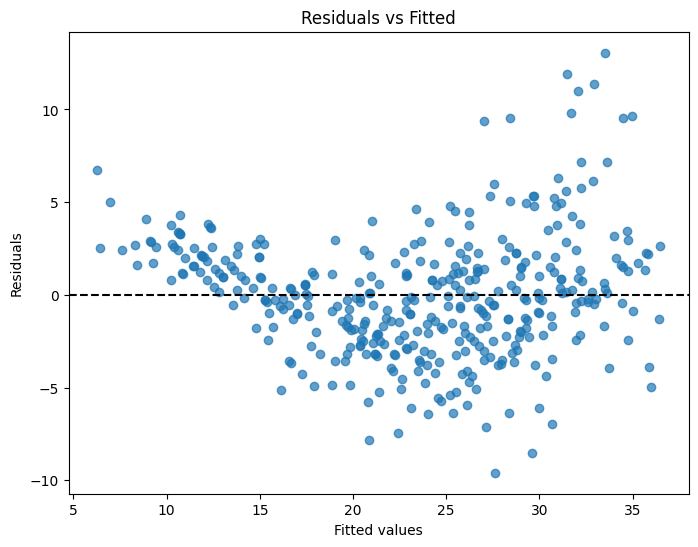

<Figure size 600x600 with 0 Axes>

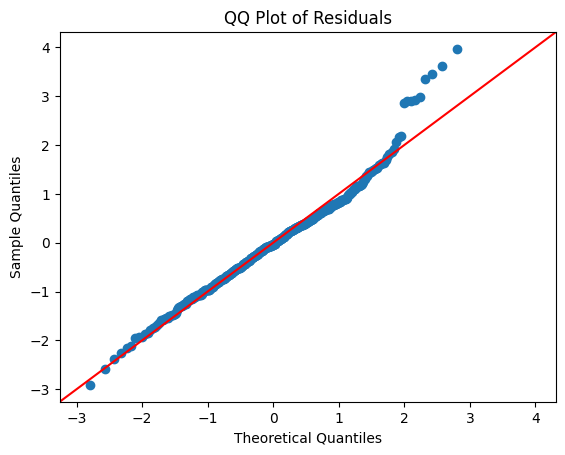

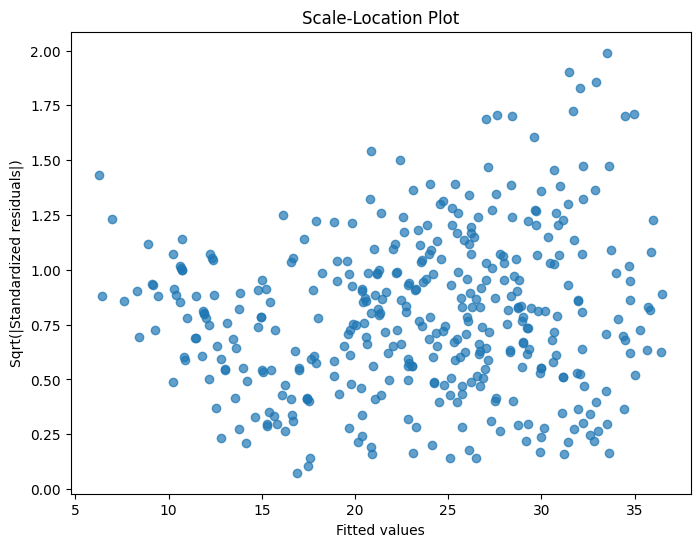

<Figure size 800x600 with 0 Axes>

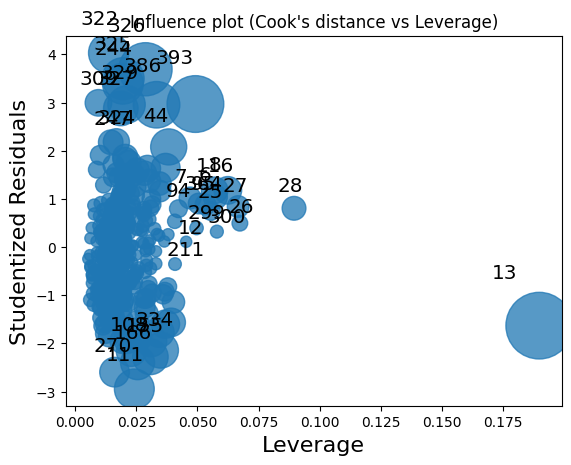

Cook's D threshold = 0.010204
Leverage threshold (2*p/n) = 0.040816

Top rows with Cook's D > 4/n (if any):
      cooks_d  student_resid  hat_diag
13   0.077801      -1.632924  0.189913
393  0.055824       2.968385  0.049172
326  0.048772       3.690246  0.028743
386  0.036773       2.953219  0.033265
325  0.029605       3.494823  0.019567

Top rows with hat_diag > 2*p/n (if any):
    hat_diag  student_resid   cooks_d
13  0.189913      -1.632924  0.077801
28  0.089541       0.803682  0.007948
26  0.067370       0.494049  0.002208
27  0.066673       0.839418  0.006297
8   0.062449       1.176401  0.011511


In [7]:
# Cell 5: Diagnostic plots
fitted_vals = model_formula.fittedvalues
residuals = model_formula.resid

# 1) Residuals vs Fitted
plt.figure(figsize=(8,6))
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# 2) QQ plot
plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.show()

# 3) Scale-Location plot
standardized_resid = (residuals - np.mean(residuals)) / np.std(residuals, ddof=1)
plt.figure(figsize=(8,6))
plt.scatter(fitted_vals, np.sqrt(np.abs(standardized_resid)), alpha=0.7)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized residuals|)")
plt.title("Scale-Location Plot")
plt.show()

# 4) Influence plot
plt.figure(figsize=(8,6))
influence_plot(model_formula, criterion="cooks")
plt.title("Influence plot (Cook's distance vs Leverage)")
plt.show()

# Identify potentially influential observations
influence = model_formula.get_influence()
summary_frame = influence.summary_frame()
n = len(df)
p = len(model_formula.params)
cooks_threshold = 4 / n
leverage_threshold = 2 * p / n

print(f"Cook's D threshold = {cooks_threshold:.6f}")
print(f"Leverage threshold (2*p/n) = {leverage_threshold:.6f}")

high_cooks = summary_frame[summary_frame['cooks_d'] > cooks_threshold].sort_values('cooks_d', ascending=False)
high_leverage = summary_frame[summary_frame['hat_diag'] > leverage_threshold].sort_values('hat_diag', ascending=False)

print("\nTop rows with Cook's D > 4/n (if any):")
print(high_cooks[['cooks_d','student_resid','hat_diag']].head())

print("\nTop rows with hat_diag > 2*p/n (if any):")
print(high_leverage[['hat_diag','student_resid','cooks_d']].head())

## (e) Models with interactions
We'll add three interactions: horsepower×weight, horsepower×year, displacement×acceleration and test their significance.

In [8]:
# Cell 6: Model with interactions (formula style)
formula_int = ("mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin "
               "+ horsepower:weight + horsepower:year + displacement:acceleration")
model_int_formula = smf.ols(formula_int, data=df).fit()

print(model_int_formula.summary())

# Print p-values for the interaction terms
print("\nInteraction term p-values:")
print(model_int_formula.pvalues[['horsepower:weight','horsepower:year','displacement:acceleration']])

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     265.2
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          7.86e-165
Time:                        15:19:10   Log-Likelihood:                -954.58
No. Observations:                 392   AIC:                             1931.
Df Residuals:                     381   BIC:                             1975.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## (f) Transformations of horsepower and comparison
We try horsepower^2, sqrt(horsepower), and log(horsepower) (replace zero with NaN if needed) and compare adjusted R² and AIC.

In [9]:
# Cell 7: Transformations and comparison
df_tr = df.copy()
df_tr['hp_sq'] = df_tr['horsepower'] ** 2
df_tr['hp_sqrt'] = np.sqrt(df_tr['horsepower'])
df_tr['hp_log'] = np.log(df_tr['horsepower'].replace(0, np.nan))

formula_base = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin"
formula_hp_sq = "mpg ~ cylinders + displacement + hp_sq + weight + acceleration + year + origin"
formula_hp_sqrt = "mpg ~ cylinders + displacement + hp_sqrt + weight + acceleration + year + origin"
formula_hp_log = "mpg ~ cylinders + displacement + hp_log + weight + acceleration + year + origin"

mod_base = smf.ols(formula_base, data=df_tr).fit()
mod_hp_sq = smf.ols(formula_hp_sq, data=df_tr).fit()
mod_hp_sqrt = smf.ols(formula_hp_sqrt, data=df_tr).fit()
mod_hp_log = smf.ols(formula_hp_log, data=df_tr).fit()

comparison = pd.DataFrame({
    'model': ['base (hp)','hp^2','sqrt(hp)','log(hp)'],
    'adj_r2': [mod_base.rsquared_adj, mod_hp_sq.rsquared_adj, mod_hp_sqrt.rsquared_adj, mod_hp_log.rsquared_adj],
    'AIC': [mod_base.aic, mod_hp_sq.aic, mod_hp_sqrt.aic, mod_hp_log.aic]
})
print(comparison.round(4))

print("\nNote: check coefficients and p-values of the transformed-variable models to see whether the transformation improves interpretability or fit.")

       model  adj_r2        AIC
0  base (hp)  0.8182  2062.9495
1       hp^2  0.8193  2060.6524
2   sqrt(hp)  0.8237  2050.9587
3    log(hp)  0.8340  2027.3834

Note: check coefficients and p-values of the transformed-variable models to see whether the transformation improves interpretability or fit.


## Final brief comments / interpretation (summary)
- Use the ANOVA table printed earlier to decide whether the full set of predictors collectively explains a significant portion of `mpg` variation (look at the PR(>F) for the model or the F-statistic in the model summary).  
- Check individual p-values from the multiple regression summary to see which predictors are statistically significant.  
- The `year` coefficient: the printed coefficient value indicates the change in mpg associated with a one-unit increase in `year` (i.e., newer model year) **holding the other predictors constant**. A positive coefficient suggests newer cars get better mpg controlling for the other variables.  
- Diagnostics: inspect Residuals vs Fitted and Scale-Location for heteroscedasticity or non-linearity, the QQ plot for normality issues, and the influence plot + Cook's D / hat values to find potentially influential observations.  
- Interactions: check p-values of interaction terms printed above — significant interaction terms imply the effect of one predictor depends on the level of another predictor.  
- Transformations: compare adjusted R² and AIC among models with transformed horsepower — choose a transform that improves adjusted R² (or reduces AIC) and makes substantive sense.